# Anomaly Detection - Isolation Forest

## Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/featured_reviews.csv")
print(df.shape)
df.head()

(6232, 13)


,reviewID,productASIN,content_clean,rating,near_dup_score,is_burst_day,is_unverified,rating_deviation,exclamation_count,word_count,avg_word_len,positive_superlative_count,negative_superlative_count
0,R2AUQFPJY5ERCZ,B0DLGB4RYH,the coofandy men's polo shirt is a fantastic b...,5.0,0.467087,0.0,1.0,1.00,0.000000,0.082956,0.423004,0.250,0.0
1,R1YNLJ0QFLB1VT,B0DRXF62JH,i love these. they look good. they fit well. t...,5.0,0.355481,0.0,1.0,0.05,0.000000,0.018854,0.297913,0.000,0.0
2,R11LIYW9RMDK9R,B0DRXF62JH,my expectations were low -- how good could shi...,4.0,0.318608,0.0,1.0,0.20,0.000000,0.060709,0.360215,0.000,0.0
3,R3K9X391DJNTPZ,B0DRXF62JH,this 3-pack of multi-color shirts is really a ...,5.0,0.427953,0.0,1.0,0.05,0.044444,0.030543,0.368214,0.125,0.0
4,RP17IW9ZKENDZ,B0DRXF62JH,with these three polo shirts i was very satisf...,5.0,0.364305,1.0,1.0,0.05,0.000000,0.017722,0.421371,0.000,0.0


## Data Preparation

In [2]:
feature_cols = ['near_dup_score', 'is_burst_day', 'is_unverified', 'rating_deviation',
                'exclamation_count', 'word_count', 'avg_word_len',
                'positive_superlative_count', 'negative_superlative_count']

X = df[feature_cols]
print(X.shape)
X.describe()

(6232, 9)


,near_dup_score,is_burst_day,is_unverified,rating_deviation,exclamation_count,word_count,avg_word_len,positive_superlative_count,negative_superlative_count
count,6232.000000,6232.00000,6232.000000,6232.000000,6232.000000,6232.000000,6232.000000,6232.000000,6232.000000
mean,0.411824,0.09708,0.024551,0.129347,0.010769,0.022835,0.338578,0.037468,0.002835
std,0.140194,0.29609,0.154764,0.133189,0.028867,0.033568,0.065542,0.081242,0.034449
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.322546,0.00000,0.000000,0.044444,0.000000,0.005656,0.299325,0.000000,0.000000
50%,0.374286,0.00000,0.000000,0.088889,0.000000,0.013198,0.326165,0.000000,0.000000
75%,0.457036,0.00000,0.000000,0.155556,0.022222,0.026772,0.365947,0.000000,0.000000
max,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Fit isolation forest

In [3]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,      # number of trees 
    contamination=0.1,     # assumption: ~10% of reviews are suspicious 
    max_samples='auto',
    random_state=42
)

iso.fit(X)

df['iso_prediction'] = iso.predict(X)          # -1 = anomaly, 1 = normal
df['iso_anomaly_score'] = iso.decision_function(X)  # continuous score, LOWER = more anomalous

print(df['iso_prediction'].value_counts())
print(df['iso_anomaly_score'].describe())

iso_prediction
 1    5608
-1     624
Name: count, dtype: int64
count    6232.000000
mean        0.096335
std         0.065313
min        -0.210000
25%         0.060604
50%         0.119598
75%         0.145593
max         0.165723
Name: iso_anomaly_score, dtype: float64


## Most suspicious reviews

In [4]:
top_suspicious = df.sort_values('iso_anomaly_score').head(20)
top_suspicious[['reviewID', 'productASIN', 'rating', 'content_clean'] + feature_cols]

,reviewID,productASIN,rating,content_clean,near_dup_score,is_burst_day,is_unverified,rating_deviation,exclamation_count,word_count,avg_word_len,positive_superlative_count,negative_superlative_count
6108,R2D65DF75P86QF,B07J31WFNB,5.0,this is unbelieveable! i normally do not give ...,0.475354,0.0,0.0,0.111111,0.177778,0.360860,0.290828,1.000,0.000000
1045,R1YA5WLWOR9F0Y,B0018ON68A,3.0,updated 11-15-2023 - original 2020 review foll...,0.474306,0.0,0.0,0.355556,0.444444,1.000000,0.358681,0.125,0.000000
964,R3TEEYSF365OL9,B07BJKWX4Y,1.0,"ok, so this is just a bad product, not terribl...",0.479857,0.0,0.0,0.680000,0.000000,0.248492,0.295748,0.000,1.000000
6142,R2579OG899E6ZX,B09K1K8117,5.0,i recently purchased a pair of levi strauss si...,0.582695,0.0,0.0,1.000000,0.088889,0.153469,0.402751,0.250,0.000000
0,R2AUQFPJY5ERCZ,B0DLGB4RYH,5.0,the coofandy men's polo shirt is a fantastic b...,0.467087,0.0,1.0,1.000000,0.000000,0.082956,0.423004,0.250,0.000000
1125,RZPZ7FW2X2UWR,B07BHKQ8SM,5.0,"hold onto your belts, gentlemenbecause the lee...",0.399733,0.0,0.0,1.000000,0.111111,0.110106,0.371573,0.375,0.000000
2980,R242ZPVXOJDD2X,B000U62IYK,1.0,i waited almost a year to post this review to ...,0.314200,0.0,0.0,0.688889,0.000000,0.254148,0.363871,0.375,0.000000
676,R2WINYHGU0YQH9,B0775MHKD6,5.0,i've worn a variety of button-up shirts over t...,0.488401,0.0,0.0,0.111111,0.066667,0.274887,0.325851,0.250,0.333333
59,R2GF00OJ5KIFJC,B0DPQC1NSV,5.0,i recently got the m maelreg men's golf shirts...,0.559141,0.0,1.0,0.044444,0.000000,0.099170,0.395161,0.375,0.000000
6101,RQ6BMMBAQG1MV,B0DSW6C8PT,5.0,this women's cow leather belt is the perfect a...,0.527762,0.0,1.0,0.066667,0.044444,0.079186,0.398104,0.375,0.000000


## Feature comparison : normal vs anomalous reviews

In [5]:
comparison = df.groupby('iso_prediction')[feature_cols].mean()
print(comparison)

                near_dup_score  is_burst_day  is_unverified  rating_deviation  \
iso_prediction                                                                  
-1                    0.478054      0.322115       0.241987          0.174712   
 1                    0.404454      0.072040       0.000357          0.124299   

                exclamation_count  word_count  avg_word_len  \
iso_prediction                                                
-1                       0.033405    0.055878      0.377294   
 1                       0.008250    0.019158      0.334270   

                positive_superlative_count  negative_superlative_count  
iso_prediction                                                          
-1                                0.123397                    0.021902  
 1                                0.027907                    0.000713  


## Sensitivity to contamination
Different contamination assumptions were tested to examine the sensitivity of the Isolation Forest results to the assumed proportion of anomalies.

In [6]:
for c in [0.05, 0.10, 0.15, 0.20]:
    iso_test = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    preds = iso_test.fit_predict(X)
    n_flagged = (preds == -1).sum()
    print(f"contamination={c}: {n_flagged} reviews flagged ({n_flagged/len(df)*100:.1f}%)")

contamination=0.05: 312 reviews flagged (5.0%)
contamination=0.1: 624 reviews flagged (10.0%)
contamination=0.15: 935 reviews flagged (15.0%)
contamination=0.2: 1247 reviews flagged (20.0%)


## Model Stability Evaluation

Since the dataset does not contain ground-truth anomaly labels, traditional
classification metrics such as accuracy, precision, recall, and F1-score
cannot be calculated directly.

Instead, model stability is evaluated by training Isolation Forest multiple
times using different random seeds and measuring how consistently the same
reviews are identified as anomalous.

In [9]:
import numpy as np
from sklearn.ensemble import IsolationForest

seeds = range(10)

anomaly_results = []

for seed in seeds:

    iso_stability = IsolationForest(
        n_estimators=200,
        contamination=0.10,
        max_samples='auto',
        random_state=seed
    )

    predictions = iso_stability.fit_predict(X)

    anomaly_results.append(predictions == -1)

anomaly_results = np.array(anomaly_results)

# Percentage of runs in which each review was classified as anomalous
df['anomaly_frequency'] = anomaly_results.mean(axis=0)

print("Stability analysis completed.")
print(df['anomaly_frequency'].describe())

Stability analysis completed.
count    6232.000000
mean        0.100128
std         0.288316
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: anomaly_frequency, dtype: float64


## Most Stable Anomalies

In [10]:
stable_anomalies = (
    df.sort_values(
        ['anomaly_frequency', 'iso_anomaly_score'],
        ascending=[False, True]
    )
    .head(20)
)

stable_anomalies[
    [
        'reviewID',
        'productASIN',
        'rating',
        'iso_anomaly_score',
        'anomaly_frequency',
        'content_clean'
    ]
]

,reviewID,productASIN,rating,iso_anomaly_score,anomaly_frequency,content_clean
6108,R2D65DF75P86QF,B07J31WFNB,5.0,-0.210000,1.0,this is unbelieveable! i normally do not give ...
1045,R1YA5WLWOR9F0Y,B0018ON68A,3.0,-0.199853,1.0,updated 11-15-2023 - original 2020 review foll...
964,R3TEEYSF365OL9,B07BJKWX4Y,1.0,-0.193059,1.0,"ok, so this is just a bad product, not terribl..."
6142,R2579OG899E6ZX,B09K1K8117,5.0,-0.190789,1.0,i recently purchased a pair of levi strauss si...
0,R2AUQFPJY5ERCZ,B0DLGB4RYH,5.0,-0.187399,1.0,the coofandy men's polo shirt is a fantastic b...
1125,RZPZ7FW2X2UWR,B07BHKQ8SM,5.0,-0.185217,1.0,"hold onto your belts, gentlemenbecause the lee..."
2980,R242ZPVXOJDD2X,B000U62IYK,1.0,-0.180487,1.0,i waited almost a year to post this review to ...
676,R2WINYHGU0YQH9,B0775MHKD6,5.0,-0.173123,1.0,i've worn a variety of button-up shirts over t...
59,R2GF00OJ5KIFJC,B0DPQC1NSV,5.0,-0.169589,1.0,i recently got the m maelreg men's golf shirts...
6101,RQ6BMMBAQG1MV,B0DSW6C8PT,5.0,-0.167211,1.0,this women's cow leather belt is the perfect a...


## Stability distribution

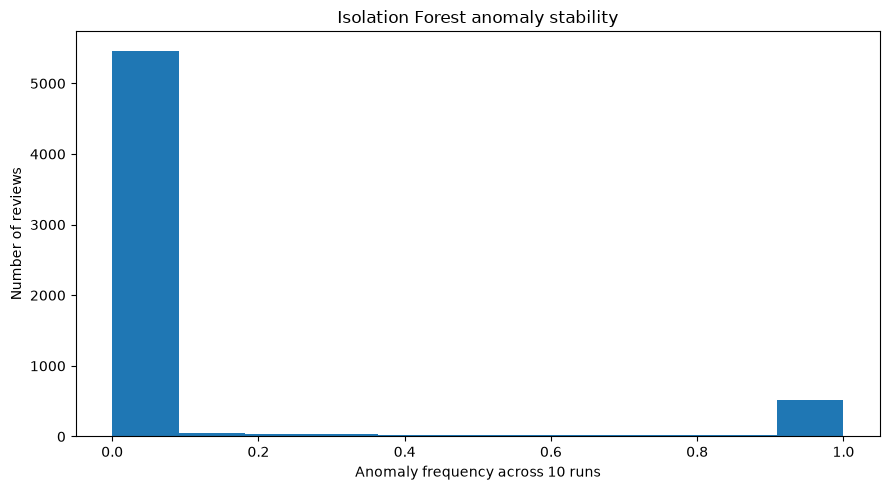

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    df['anomaly_frequency'],
    bins=11
)

plt.xlabel('Anomaly frequency across 10 runs')
plt.ylabel('Number of reviews')
plt.title('Isolation Forest anomaly stability')

plt.tight_layout()
plt.show()

## Anomaly score distribution

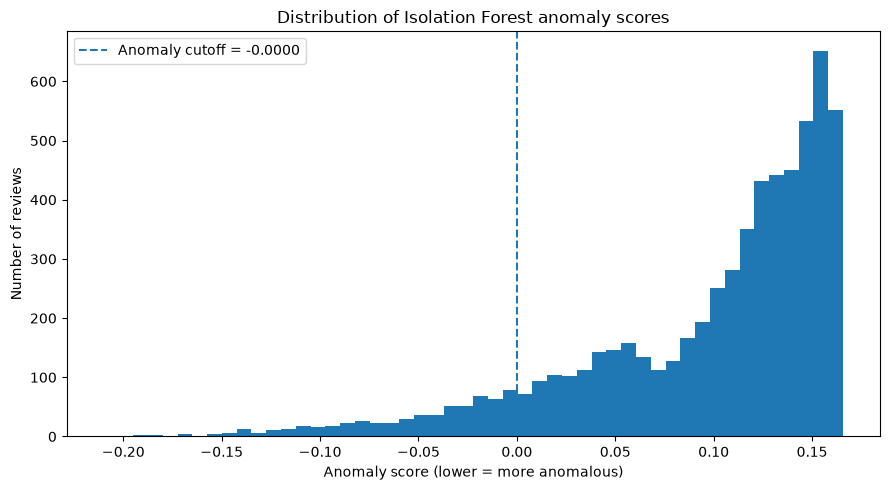

In [12]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['iso_anomaly_score'],
    bins=50
)

anomaly_cutoff = df.loc[
    df['iso_prediction'] == -1,
    'iso_anomaly_score'
].max()

plt.axvline(
    anomaly_cutoff,
    linestyle='--',
    label=f'Anomaly cutoff = {anomaly_cutoff:.4f}'
)

plt.title('Distribution of Isolation Forest anomaly scores')
plt.xlabel('Anomaly score (lower = more anomalous)')
plt.ylabel('Number of reviews')
plt.legend()

plt.tight_layout()
plt.show()

# Feature Analysis

In [13]:
normal_mean = df.loc[
    df['iso_prediction'] == 1,
    feature_cols
].mean()

anomaly_mean = df.loc[
    df['iso_prediction'] == -1,
    feature_cols
].mean()

feature_analysis = pd.DataFrame({
    'normal_mean': normal_mean,
    'anomaly_mean': anomaly_mean
})

feature_analysis['absolute_difference'] = (
    feature_analysis['anomaly_mean']
    - feature_analysis['normal_mean']
).abs()

feature_analysis = feature_analysis.sort_values(
    'absolute_difference',
    ascending=False
)

feature_analysis.round(4)

,normal_mean,anomaly_mean,absolute_difference
is_burst_day,0.0720,0.3221,0.2501
is_unverified,0.0004,0.2420,0.2416
positive_superlative_count,0.0279,0.1234,0.0955
near_dup_score,0.4045,0.4781,0.0736
rating_deviation,0.1243,0.1747,0.0504
avg_word_len,0.3343,0.3773,0.0430
word_count,0.0192,0.0559,0.0367
exclamation_count,0.0083,0.0334,0.0252
negative_superlative_count,0.0007,0.0219,0.0212


# Feature Separation Visualization

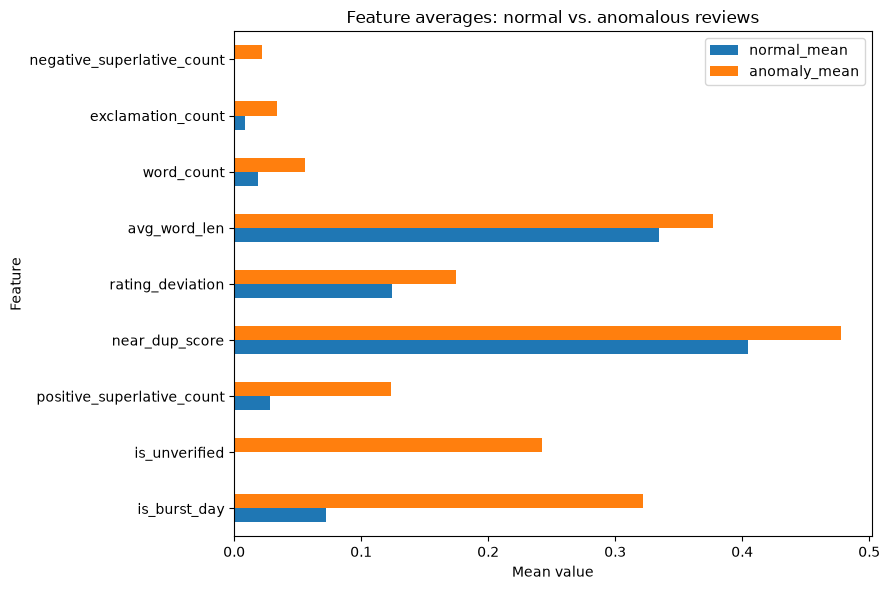

In [14]:
feature_analysis[['normal_mean', 'anomaly_mean']].plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Feature averages: normal vs. anomalous reviews')
plt.xlabel('Mean value')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# Final Isolation Forest Summary

In [15]:
print("=" * 60)
print("ISOLATION FOREST — FINAL SUMMARY")
print("=" * 60)

n_total = len(df)

n_flagged = (
    df['iso_prediction'] == -1
).sum()

n_normal = (
    df['iso_prediction'] == 1
).sum()

print(f"\nTotal reviews analyzed: {n_total}")
print(
    f"Flagged as anomalous:   "
    f"{n_flagged} ({n_flagged / n_total * 100:.1f}%)"
)
print(
    f"Flagged as normal:      "
    f"{n_normal} ({n_normal / n_total * 100:.1f}%)"
)

print("\nInitial contamination assumption: 10%")

print("\nMost anomalous reviews:")
print(
    df.sort_values('iso_anomaly_score')[
        [
            'reviewID',
            'productASIN',
            'rating',
            'iso_anomaly_score',
            'anomaly_frequency'
        ]
    ].head(10)
)

ISOLATION FOREST — FINAL SUMMARY

Total reviews analyzed: 6232
Flagged as anomalous:   624 (10.0%)
Flagged as normal:      5608 (90.0%)

Initial contamination assumption: 10%

Most anomalous reviews:
            reviewID productASIN  rating  iso_anomaly_score  anomaly_frequency
6108  R2D65DF75P86QF  B07J31WFNB     5.0          -0.210000                1.0
1045  R1YA5WLWOR9F0Y  B0018ON68A     3.0          -0.199853                1.0
964   R3TEEYSF365OL9  B07BJKWX4Y     1.0          -0.193059                1.0
6142  R2579OG899E6ZX  B09K1K8117     5.0          -0.190789                1.0
0     R2AUQFPJY5ERCZ  B0DLGB4RYH     5.0          -0.187399                1.0
1125   RZPZ7FW2X2UWR  B07BHKQ8SM     5.0          -0.185217                1.0
2980  R242ZPVXOJDD2X  B000U62IYK     1.0          -0.180487                1.0
676   R2WINYHGU0YQH9  B0775MHKD6     5.0          -0.173123                1.0
59    R2GF00OJ5KIFJC  B0DPQC1NSV     5.0          -0.169589                1.0
6101   RQ6

# Save Results

In [16]:
output_cols = [
    'reviewID',
    'productASIN',
    'rating',
    'content_clean'
] + feature_cols + [
    'iso_prediction',
    'iso_anomaly_score',
    'anomaly_frequency'
]

output_path = '../data/processed/anomaly_scored_reviews.csv'

df[output_cols].to_csv(
    output_path,
    index=False
)

print('Saved:', output_path)
print('Output shape:', df[output_cols].shape)

Saved: ../data/processed/anomaly_scored_reviews.csv
Output shape: (6232, 16)
